## 1. Import Required Libraries

In [15]:
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.cuda.is_available()

True

In [16]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA version PyTorch was built with: {torch.version.cuda}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Compute Capability: {torch.cuda.get_device_capability(0)}")

PyTorch version: 2.10.0+cu128
CUDA version PyTorch was built with: 12.8
GPU Name: NVIDIA GeForce RTX 5070
GPU Compute Capability: (12, 0)


### 2. Preparing Images

In [17]:
train_df = pd.read_csv("sign_mnist_train.csv")
test_df = pd.read_csv("sign_mnist_valid.csv")

# --- 1. Constants ---

In [18]:
IMG_HEIGHT = 28
IMG_WIDTH = 28
IMG_CHS = 1
BATCH_SIZE = 16
EPOCHS = 10
LR = 0.001
NUM_CLASSES = len(train_df['label'].unique())

# --- 2. Preprocess Data ---

In [19]:
y_train_df = train_df.pop('label')
x_train_df = train_df

y_test_df = test_df.pop('label')
x_test_df = test_df

# Normalize and reshape

In [20]:
x_train = x_train_df.values.reshape(-1, IMG_CHS, IMG_HEIGHT, IMG_WIDTH) / 255.0
x_test = x_test_df.values.reshape(-1, IMG_CHS, IMG_HEIGHT, IMG_WIDTH) / 255.0


In [21]:
y_train = y_train_df.values
y_test = y_test_df.values

In [22]:
print(f"Training data shape: {x_train.shape}")
print(f"Validation data shape: {x_test.shape}")
print(f"Number of classes: {NUM_CLASSES}")

Training data shape: (27455, 1, 28, 28)
Validation data shape: (7172, 1, 28, 28)
Number of classes: 24


## Creat loader

In [23]:
class ASLDataset(Dataset):
    def __init__(self, images, labels):
        self.images = torch.tensor(images, dtype=torch.float32).to(device)
        self.labels = torch.tensor(labels, dtype=torch.long).to(device)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

train_dataset = ASLDataset(x_train, y_train)
test_dataset = ASLDataset(x_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Verify one batch
x_batch, y_batch = next(iter(train_loader))
print(f"Batch of images shape: {x_batch.shape}")
print(f"Batch of labels shape: {y_batch.shape}")


Batch of images shape: torch.Size([16, 1, 28, 28])
Batch of labels shape: torch.Size([16])


## CNN model

In [24]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(IMG_CHS, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SimpleCNN(num_classes=NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=LR)

print(model)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=24, bias=True)
  )
)


## start training

In [25]:
train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = correct_train / total_train
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    model.eval()
    running_loss = 0.0
    correct_test = 0
    total_test = 0
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()

    test_loss = running_loss / len(test_loader)
    test_acc = correct_test / total_test
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} - "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} - "
          f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

Epoch 1/10 - Train Loss: 0.5755, Train Acc: 0.8243 - Test Loss: 0.3356, Test Acc: 0.9074
Epoch 2/10 - Train Loss: 0.0268, Train Acc: 0.9945 - Test Loss: 0.3537, Test Acc: 0.9235
Epoch 3/10 - Train Loss: 0.0114, Train Acc: 0.9966 - Test Loss: 0.3425, Test Acc: 0.9011
Epoch 4/10 - Train Loss: 0.0029, Train Acc: 0.9994 - Test Loss: 0.4081, Test Acc: 0.9290
Epoch 5/10 - Train Loss: 0.0164, Train Acc: 0.9949 - Test Loss: 0.3959, Test Acc: 0.9235
Epoch 6/10 - Train Loss: 0.0004, Train Acc: 1.0000 - Test Loss: 0.4498, Test Acc: 0.9299
Epoch 7/10 - Train Loss: 0.0001, Train Acc: 1.0000 - Test Loss: 0.4817, Test Acc: 0.9303
Epoch 8/10 - Train Loss: 0.0000, Train Acc: 1.0000 - Test Loss: 0.5252, Test Acc: 0.9299
Epoch 9/10 - Train Loss: 0.0000, Train Acc: 1.0000 - Test Loss: 0.5522, Test Acc: 0.9343
Epoch 10/10 - Train Loss: 0.0162, Train Acc: 0.9951 - Test Loss: 0.3108, Test Acc: 0.9407


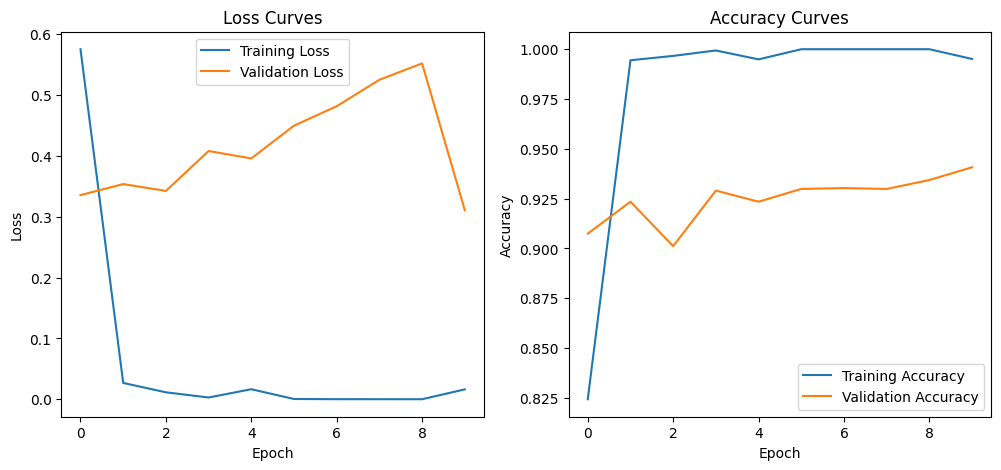

In [26]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Training Loss')
plt.plot(test_losses, label='Validation Loss')
plt.title('Loss Curves')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(test_accuracies, label='Validation Accuracy')
plt.title('Accuracy Curves')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       331
           1       1.00      1.00      1.00       432
           2       1.00      1.00      1.00       310
           3       0.98      1.00      0.99       245
           4       1.00      0.96      0.98       498
           5       0.99      1.00      0.99       247
           6       0.90      0.94      0.92       348
           7       0.91      0.92      0.91       436
           8       0.88      1.00      0.94       288
           9       0.98      0.93      0.95       331
          10       0.91      1.00      0.95       209
          11       0.96      0.95      0.95       394
          12       0.83      0.79      0.81       291
          13       1.00      0.91      0.95       246
          14       0.94      1.00      0.97       347
          15       0.91      0.99      0.95       164
          16       0.80      1.00      0.89       144
    

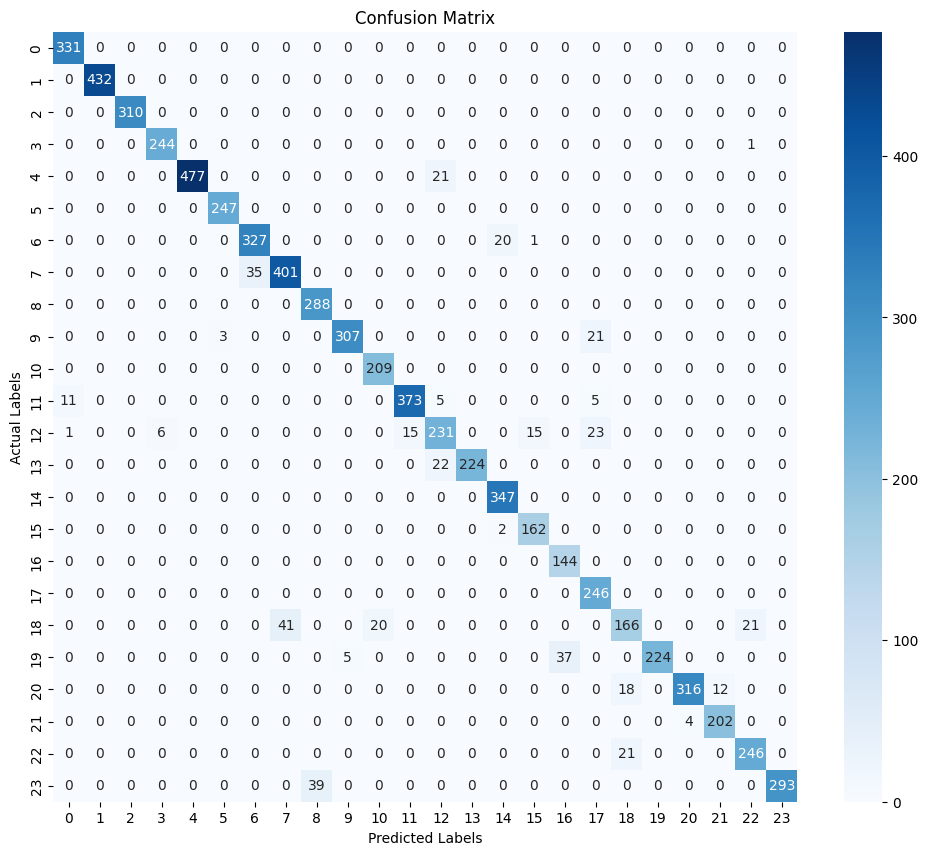

In [27]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# Get predictions for the entire test set
all_preds = []
all_labels = []
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# 1. Classification Report
print("Classification Report:")
print(classification_report(all_labels, all_preds))

# 2. Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual Labels')
plt.xlabel('Predicted Labels')
plt.show()

In [28]:
from sklearn.metrics import accuracy_score

# Calculate the overall accuracy
accuracy = accuracy_score(all_labels, all_preds)

print(f"Overall Accuracy Score: {accuracy:.4f}")

Overall Accuracy Score: 0.9407


### Performance Analysis

**1. Is the training accuracy much higher than the validation accuracy?**

Yes, the training accuracy is consistently higher than the validation accuracy. This is expected, as the model is optimized on the training data. A large gap between the two can be an indicator of overfitting, meaning the model has learned the training data too well, including its noise, and struggles to generalize to new, unseen data like the validation set.

**2. Does the validation loss increase while training loss decreases?**

In the later epochs, it is common to see the validation loss stagnate or start to increase while the training loss continues to decrease. This is a classic sign of overfitting. It means that beyond a certain point, further training on the same data helps the model memorize the training set but makes it perform worse on the validation set.